# Fitting more complex models to photometry with Bagpipes

In the previos example we covered some of the basics, now let's look at fitting a more complex model.

## Setting up

Once again we'll need to load up the observational data, we'll use the same object as last time.

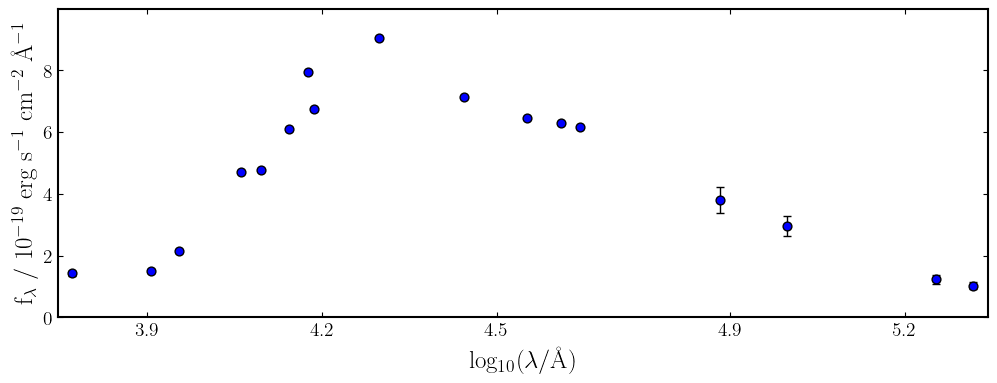

In [29]:
import os
# Example for macOS MacTeX. Adjust path for Linux or Windows.
#os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/'

import numpy as np 
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

from astropy.cosmology import WMAP9 as cosmo
import bagpipes as pipes
import matplotlib.pyplot as plt
#%matplotlib inline

from astropy.io import fits
from astropy.table import Table

def load_bluejay(ID):
    """ Load BlueJay photometry from the BlueJay catalogue(s)"""

    # Blue Jay catalogue
    bluejay_cat = Table.read("bluejay_phot_cat_v1.4.fits")
    
    # 1. List all available HST/NIRCam bands:
    filters = ['F090W', 'F115W', 'F125W', 'F140W', 'F150W', 'F160W', 
               'F200W', 'F277W', 'F356W', 'F410M', 'F444W', 'F606W', 'F814W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = bluejay_cat[bluejay_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    fluxes = []
    flux_errs = []

    for f in filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)


    # MIRI catalogue
    miri_cat = Table.read("Phot_Table_MIRI.fits")
    
    # 1. List all available MIRI bands:
    miri_filters = ['F770W', 'F1000W', 'F1800W', 'F2100W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = miri_cat[miri_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    for f in miri_filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)
    
    # Now turn these into a 2D array [N_filters, 2]
    # Bagpipes expects photometry[i, 0] = flux, photometry[i, 1] = error
    photometry = np.c_[fluxes, flux_errs]
    
    # 5. Clean up missing data and enforce SNR limits
    for i in range(len(photometry)):
        # Blow up errors for missing data (NaN or 0 flux)
        if (photometry[i, 0] <= 0.) or (np.isnan(photometry[i, 0])):
            photometry[i, :] = [0., 9.9e99]
            continue # Skip SNR check for bad data
    
    return photometry

bluejay_filt_list = np.loadtxt("filters/bluejay_filt_list.txt", dtype="str")

galaxy = pipes.galaxy("12020", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)

fig = galaxy.plot()

# Replicating the Prospector Model

Specify all parameters such that they match the Prospector model that Letizia used for my galaxies.

Prospector Parameter    Bagpipes Equivalent     Translation Notes
zred                    redshift                "Use (1.764, 0.5) for a Gaussian."
logzsol                 metallicity             Convert log to linear (10−2 to 100.5).
logmass                 massformed              "Bagpipes uses total formed mass, not current stellar mass."
dust2                   Av                      AV​=1.086×optical depth.
dust_index              eta                     Bagpipes' cf00 model uses eta for the slope.

Set up the `fit_instructions` dictionary

In [30]:
# Redshift
def get_zred(galaxy_id):    
    # --- Read Blue Jay catalogue ---
    blue = "/Users/benjamincollins/University/Master/BlueJay/BlueJay_sample.txt"
    tbl = Table.read(blue, format="ascii.basic")
    
    row = tbl[tbl['id'] == int(galaxy_id)]
    
    # Make sure that the code doesn't crash if it can't find the ID in the catalogue
    if len(row) == 0:   
        return None, False
    
    z_spec = row['z_spec'][0]
    
    if z_spec is not None and not np.isnan(z_spec):
        return z_spec, True
    else:
        z_phot = row['z_phot'][0]
        return z_phot, False

# Star formation histories
def zred_to_agebins(zred, z_limit_sfh=20.0, nbins_sfh=8):
    tuniv = cosmo.age(zred).value*1e9   # Age of the universe at the observed redshift in years
    #tbinmax = tuniv-cosmo.age(z_limit_sfh).value*1e9 # Maximum age bin edge corresponding to z_limit_sfh
    tbinmax = tuniv*0.95
    # Compute edges in logarithmic space
    log_edges = np.append(np.array([0.0, 6.7, 7.0]), np.linspace(7.0, np.log10(tbinmax), int(nbins_sfh-1))[1:])
    bin_edges = 10**log_edges   # Convert back to linear space
    bin_edges /= 1e6 # ensure that edges are in Myr for Bagpipes
    return bin_edges.tolist()   # return list of age bin edges

fit_instructions = {}                       # The fit instructions dictionary

# Nebular component
nebular = {}
nebular["logU"] = (-4., -1.)                # Log_10 of the ionisation parameter.
#nebular["fesc"] = (0., 1.)                  # IMPORTANT: Escape fraction of ionising photons. Standard value is 0.1

# Dust absorption parameters
dust = {}                               # Dust component
dust["type"] = "CF00"                   # Define the shape of the attenuation curve
dust["Av"] = (0., 4.0)                  # Vary Av between 0 and 3.2 magnitudes
dust["n"] = (-1.0, 1.5)                 # Vary the slope of the attenuation curve from -1.0 to 1.5
dust["n_prior"] = "Gaussian"            # Set a Gaussian prior
dust["n_prior_mu"] = 0.7                # Centred on the standard CF00 slope of 0.7
dust["n_prior_sigma"] = 0.3             # With a width of 0.3

# Dust emission parameters (now free parameters)
dust["qpah"] = (0.1, 4.58)                  # PAH mass fraction (spanning the entire grid)
dust["umin"] = (0.1, 25.)                   # Lower limit of starlight intensity distribution (spanning the entire grid)
dust["gamma"] = (0., 1.0)                   # Fraction of stars at Umin

# Alternatively use a very narrow Gaussian prior centred on the spectroscopic redshift:
#fit_instructions["redshift"] = (zred-1, zred+1)     # Set the redshift prior to vary within +/1 of the spectroscopic redshift
#fit_instructions["redshift_prior"] = "Gaussian"     # Use a Gaussian prior
#fit_instructions["redshift_prior_mu"] = zred        # Centred on the spectroscopic redshift
#fit_instructions["redshift_prior_sigma"] = 0.005    # With a very narrow width

# Setting the SFH priors
continuity = {}
continuity["massformed"] = (8.5, 13)            # Log10 of solar mass formed
continuity["metallicity"] = (0.01, 3.16)        # Linear Z/Z_solar: 0.01 to 3.16
continuity["metallicity_prior"] = "log_10"      # Logarithmic prior for metallicity

# Define the dsfr ratios
for i in range(1, 7):   # for 7 bins
    continuity[f"dsfr{i}"] = (-10., 10.) 
    continuity[f"dsfr{i}_prior"] = "student_t"
    #continuity["dsfr" + str(i) + "_prior_df"] = 2       # Default nu value of 2 in the student_t distribution
    #continuity["dsfr" + str(i) + "_prior_scale"] = 0.3  # Default sigma value of 0.3 in the student_t distribution

fit_instructions["dust"] = dust
fit_instructions["nebular"] = nebular
fit_instructions["continuity"] = continuity

print(fit_instructions)

{'dust': {'type': 'CF00', 'Av': (0.0, 4.0), 'n': (-1.0, 1.5), 'n_prior': 'Gaussian', 'n_prior_mu': 0.7, 'n_prior_sigma': 0.3, 'qpah': (0.1, 4.58), 'umin': (0.1, 25.0), 'gamma': (0.0, 1.0)}, 'nebular': {'logU': (-4.0, -1.0)}, 'continuity': {'massformed': (8.5, 13), 'metallicity': (0.01, 3.16), 'metallicity_prior': 'log_10', 'dsfr1': (-10.0, 10.0), 'dsfr1_prior': 'student_t', 'dsfr2': (-10.0, 10.0), 'dsfr2_prior': 'student_t', 'dsfr3': (-10.0, 10.0), 'dsfr3_prior': 'student_t', 'dsfr4': (-10.0, 10.0), 'dsfr4_prior': 'student_t', 'dsfr5': (-10.0, 10.0), 'dsfr5_prior': 'student_t', 'dsfr6': (-10.0, 10.0), 'dsfr6_prior': 'student_t'}}


Now run the galaxy with minimal parameters

Skipping galaxy 12213 - output file already exists!
Skipping galaxy 16615 - output file already exists!
Skipping galaxy 11137 - output file already exists!
Skipping galaxy 19393 - output file already exists!
Skipping galaxy 11051 - output file already exists!
Skipping galaxy 21547 - output file already exists!
Fixing redshift to the spectroscopic value of the source: 2.05
Age bins: [1e-06, 5.011872336272725, 10.0, 31.466963085448004, 99.01697658209474, 311.57635469414447, 980.4361651459097, 3085.1348616284545]

Bagpipes: fitting object 8323



/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3559: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/lib/_index_tricks_impl.py:414: UserWarning: Warning: converting a masked element to nan.
  newobj = array(item, copy=None, subok=True, ndmin=ndmin)


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 25     | 2        | 4        | 41412    | N/A    | 2     | +79.48   

Completed in 123.0 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1               0.135      0.135      0.169
continuity:dsfr2               0.614      0.614      0.731
continuity:dsfr3              -0.683     

/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3559: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/lib/_index_tricks_impl.py:414: UserWarning: Warning: converting a masked element to nan.
  newobj = array(item, copy=None, subok=True, ndmin=ndmin)


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 43     | 2        | 4        | 108528   | N/A    | 103   | +256.28  

Completed in 377.2 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1               0.152      0.324      0.564
continuity:dsfr2               0.327      0.460      0.654
continuity:dsfr3               0.436     

...

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 2        | 4        | 36006    | N/A    | 5     | +68.67   

Completed in 122.7 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1              -0.378     -0.329     -0.213
continuity:dsfr2              -0.687     -0.670     -0.222
continuity:dsfr3              -0.852     

/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3559: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/lib/_index_tricks_impl.py:414: UserWarning: Warning: converting a masked element to nan.
  newobj = array(item, copy=None, subok=True, ndmin=ndmin)


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 30     | 2        | 4        | 43146    | N/A    | 35    | +39.62   

Completed in 134.0 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1              -0.272     -0.186     -0.038
continuity:dsfr2              -0.142      0.008      0.174
continuity:dsfr3              -0.054     

/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3559: UserWarning: Warning: converting a masked element to nan.
  return asarray(a).ndim
/opt/anaconda3/envs/bagpipes/lib/python3.11/site-packages/numpy/lib/_index_tricks_impl.py:414: UserWarning: Warning: converting a masked element to nan.
  newobj = array(item, copy=None, subok=True, ndmin=ndmin)


Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 73     | 2        | 4        | 208284   | N/A    | 278   | -479.25  

Completed in 716.7 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1              -1.089     -0.990     -0.893
continuity:dsfr2               0.127      0.207      0.282
continuity:dsfr3               0.521     

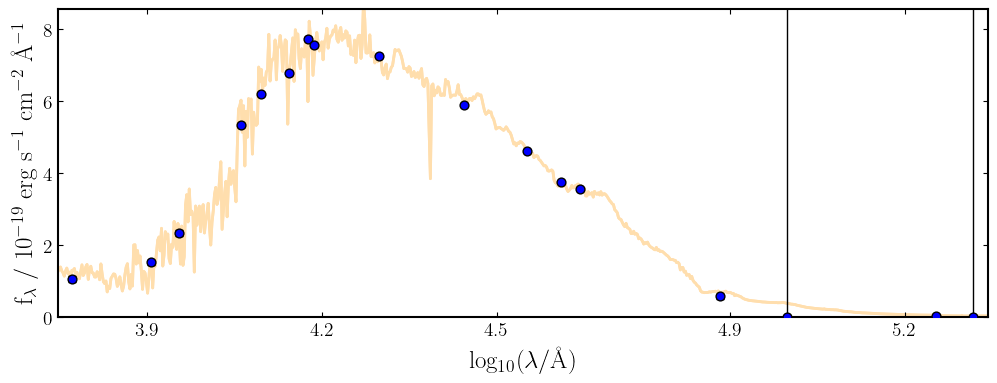

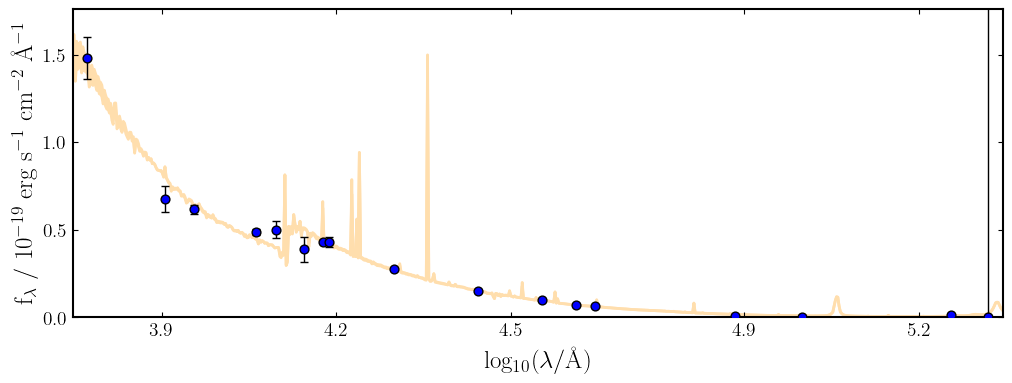

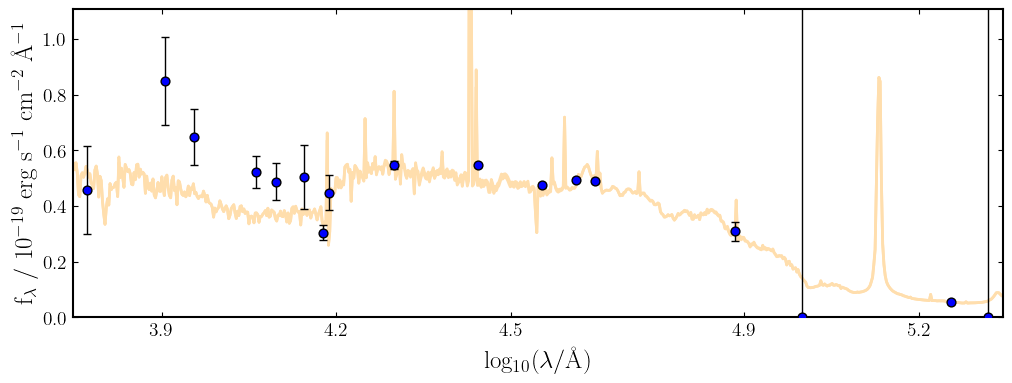

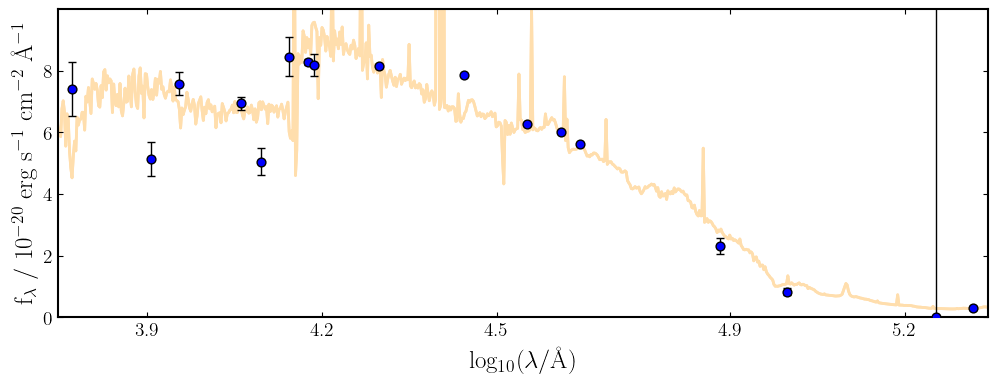

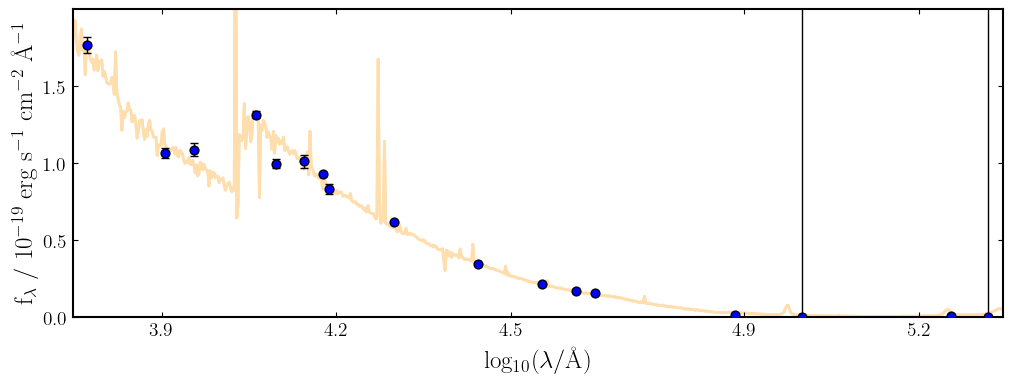

In [ ]:
run = "no_fesc_with_miri"

# Step 1: Get all IDs from the MIRI catalogue
miri_table = "./Phot_Table_MIRI.fits"
id_table = Table.read(miri_table)
all_ids = [int(val.decode('utf-8') if isinstance(val, bytes) else val) 
                        for val in id_table['ID']]

# Step 2: Loop over all IDs, load the galaxy, set the redshift and SFH priors, and fit each one!
for objid in all_ids:
    
    posterior_dir = f'/Users/benjamincollins/University/PhD/Code/bagpipes/examples/pipes/posterior/{run}'
    
    filename = os.path.join(posterior_dir, f"{objid}.h5")
        
    if os.path.exists(filename):
        print(f"Skipping galaxy {objid} - output file already exists!")
        continue
    
    # Create galaxy object for the current ID
    galaxy = pipes.galaxy(f"{objid}", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)

    # Load the redshift
    zred, is_spectroscopic = get_zred(objid)
    if zred is None:
        print(f"No valid redshift found for ID {objid}. Skipping this galaxy.")
        continue

    if is_spectroscopic:
        print(f"Fixing redshift to the spectroscopic value of the source: {zred}")
        fit_instructions["redshift"] = zred                       # Fix the redshift to the spectroscopic value to reduce runtime
    else:
        print(f"Using photometric redshift of {zred} with a Gaussian prior for the source.")
        fit_instructions["redshift"] = (zred-0.25, zred+0.25)     # Set the redshift prior to vary within +/1 of the photometric redshift
        fit_instructions["redshift_prior"] = "Gaussian"           # Use a Gaussian prior
        fit_instructions["redshift_prior_mu"] = zred              # Centred on the photometric redshift
        fit_instructions["redshift_prior_sigma"] = 0.05           # With a width of 0.05

    # Calculate the agebins for the star formation history of the galaxy based on its redshift and update the fit instructions
    age_bins = zred_to_agebins(zred, nbins_sfh=7)
    print("Age bins:", age_bins)
    fit_instructions["continuity"]["bin_edges"] = age_bins   
    
    fit = pipes.fit(galaxy, fit_instructions, run=run)

    fit.fit(verbose=True, sampler='nautilus', pool=6, discard_exploration=True)

    try:
        fig = fit.plot_spectrum_posterior(save=True, show=False)
    except ValueError:
        print(f"Warning: Spectrum plot failed for {objid} due to empty photometry array.")

    try:
        fig = fit.plot_sfh_posterior(save=True, show=False)
        fig = fit.plot_corner(save=True, show=False)
    except Exception as e:
        print(f"Warning: Other plots failed for {objid}: {e}")

Load example posterior

In [ ]:
#list(fit.posterior.samples['sfr'])
list(fit.posterior.samples['nebular:fesc'])

posterior = fit.posterior.samples

print(np.shape(fit.posterior.samples['nebular:fesc']))
print(np.shape(fit.posterior.samples['sfr']))

fesc_array = fit.posterior.samples['nebular:fesc']

print(np.median(fesc_array))

(500,)
(500,)
0.04428317220737994


# Fit the data without MIRI

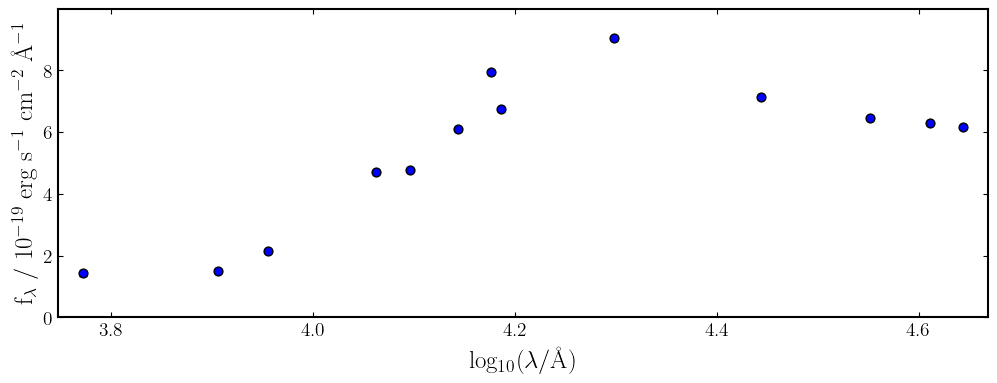

In [14]:
import numpy as np 
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

from astropy.cosmology import WMAP9 as cosmo
import bagpipes as pipes
import matplotlib.pyplot as plt
#%matplotlib inline

from astropy.io import fits
from astropy.table import Table

def load_bluejay(ID):
    """ Load BlueJay photometry from the BlueJay catalogue(s)"""

    # Blue Jay catalogue
    bluejay_cat = Table.read("bluejay_phot_cat_v1.4.fits")
    
    # 1. List all available HST/NIRCam bands:
    filters = ['F090W', 'F115W', 'F125W', 'F140W', 'F150W', 'F160W', 
               'F200W', 'F277W', 'F356W', 'F410M', 'F444W', 'F606W', 'F814W']
    
    # 2. Find the correct row using the ID column
    # Use a mask rather than (int(ID) - 1) to be safe against non-sequential IDs
    row = bluejay_cat[bluejay_cat['ID'] == int(ID)]

    if len(row) == 0:
        raise ValueError(f"ID {ID} not found in catalogue.")
    
    # 3. Extract fluxes and errors into lists
    fluxes = []
    flux_errs = []

    for f in filters:
        fluxes.append(row[f + "_flux"][0] * 1e6)
        flux_errs.append(row[f + "_flux_err"][0] * 1e6)
    
    # Now turn these into a 2D array [N_filters, 2]
    # Bagpipes expects photometry[i, 0] = flux, photometry[i, 1] = error
    photometry = np.c_[fluxes, flux_errs]
    
    # 5. Clean up missing data and enforce SNR limits
    for i in range(len(photometry)):
        # Blow up errors for missing data (NaN or 0 flux)
        if (photometry[i, 0] <= 0.) or (np.isnan(photometry[i, 0])):
            photometry[i, :] = [0., 9.9e99]
            continue # Skip SNR check for bad data
            
    return photometry

bluejay_filt_list = np.loadtxt("filters/bluejay_filt_list_nomiri.txt", dtype="str")

galaxy = pipes.galaxy("12020", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)

fig = galaxy.plot()

In [ ]:
# Redshift
def get_zred(galaxy_id):    
    # --- Read Blue Jay catalogue ---
    blue = "/Users/benjamincollins/University/Master/BlueJay/BlueJay_sample.txt"
    tbl = Table.read(blue, format="ascii.basic")
    
    row = tbl[tbl['id'] == int(galaxy_id)]
    
    # Make sure that the code doesn't crash if it can't find the ID in the catalogue
    if len(row) == 0:   
        return None, False
    
    z_spec = row['z_spec'][0]
    
    if z_spec is not None and not np.isnan(z_spec):
        return z_spec, True
    else:
        z_phot = row['z_phot'][0]
        return z_phot, False

# Star formation histories
def zred_to_agebins(zred, z_limit_sfh=20.0, nbins_sfh=8):
    tuniv = cosmo.age(zred).value*1e9   # Age of the universe at the observed redshift in years
    #tbinmax = tuniv-cosmo.age(z_limit_sfh).value*1e9 # Maximum age bin edge corresponding to z_limit_sfh
    tbinmax = tuniv*0.95
    # Compute edges in logarithmic space
    log_edges = np.append(np.array([0.0, 6.7, 7.0]), np.linspace(7.0, np.log10(tbinmax), int(nbins_sfh-1))[1:])
    bin_edges = 10**log_edges   # Convert back to linear space
    bin_edges /= 1e6 # ensure that edges are in Myr for Bagpipes
    return bin_edges.tolist()   # return list of age bin edges

fit_instructions = {}                       # The fit instructions dictionary

# Nebular component
nebular = {}
nebular["logU"] = (-4., -1.)                # Log_10 of the ionisation parameter.
nebular["fesc"] = (0., 1.)                  # IMPORTANT: Escape fraction of ionising photons. Standard value is 0.1

# Dust absorption parameters
dust = {}                               # Dust component
dust["type"] = "CF00"                   # Define the shape of the attenuation curve
dust["Av"] = (0., 4.0)                  # Vary Av between 0 and 3.2 magnitudes
dust["n"] = (-1.0, 1.5)                 # Vary the slope of the attenuation curve from -1.0 to 1.5
dust["n_prior"] = "Gaussian"            # Set a Gaussian prior
dust["n_prior_mu"] = 0.7                # Centred on the standard CF00 slope of 0.7
dust["n_prior_sigma"] = 0.3             # With a width of 0.3

# Dust emission parameters (now free parameters)
dust["qpah"] = (0.1, 4.58)                  # PAH mass fraction (spanning the entire grid)
dust["umin"] = (0.1, 25.)                   # Lower limit of starlight intensity distribution (spanning the entire grid)
dust["gamma"] = (0., 1.0)                   # Fraction of stars at Umin

# Alternatively use a very narrow Gaussian prior centred on the spectroscopic redshift:
#fit_instructions["redshift"] = (zred-1, zred+1)     # Set the redshift prior to vary within +/1 of the spectroscopic redshift
#fit_instructions["redshift_prior"] = "Gaussian"     # Use a Gaussian prior
#fit_instructions["redshift_prior_mu"] = zred        # Centred on the spectroscopic redshift
#fit_instructions["redshift_prior_sigma"] = 0.005    # With a very narrow width

# Setting the SFH priors
continuity = {}
continuity["massformed"] = (8.5, 13)            # Log10 of solar mass formed
continuity["metallicity"] = (0.01, 3.16)        # Linear Z/Z_solar: 0.01 to 3.16
continuity["metallicity_prior"] = "log_10"      # Logarithmic prior for metallicity

# Define the dsfr ratios
for i in range(1, 7):   # for 7 bins
    continuity[f"dsfr{i}"] = (-10., 10.) 
    continuity[f"dsfr{i}_prior"] = "student_t"
    #continuity["dsfr" + str(i) + "_prior_df"] = 2       # Default nu value of 2 in the student_t distribution
    #continuity["dsfr" + str(i) + "_prior_scale"] = 0.3  # Default sigma value of 0.3 in the student_t distribution

fit_instructions["dust"] = dust
fit_instructions["nebular"] = nebular
fit_instructions["continuity"] = continuity

print(fit_instructions)

{'dust': {'type': 'CF00', 'Av': (0.0, 4.0), 'n': (-1.0, 1.5), 'n_prior': 'Gaussian', 'n_prior_mu': 0.7, 'n_prior_sigma': 0.3, 'qpah': (0.1, 4.58), 'umin': (0.1, 25.0), 'gamma': (0.0, 1.0)}, 'nebular': {'logU': (-4.0, -1.0)}, 'continuity': {'massformed': (8.5, 13), 'metallicity': (0.01, 3.16), 'metallicity_prior': 'log_10', 'dsfr1': (-10.0, 10.0), 'dsfr1_prior': 'student_t', 'dsfr2': (-10.0, 10.0), 'dsfr2_prior': 'student_t', 'dsfr3': (-10.0, 10.0), 'dsfr3_prior': 'student_t', 'dsfr4': (-10.0, 10.0), 'dsfr4_prior': 'student_t', 'dsfr5': (-10.0, 10.0), 'dsfr5_prior': 'student_t', 'dsfr6': (-10.0, 10.0), 'dsfr6_prior': 'student_t'}}


In [ ]:
run = "fesc_with_miri"

# Step 1: Get all IDs from the MIRI catalogue
miri_table = "./Phot_Table_MIRI.fits"
id_table = Table.read(miri_table)
all_ids = [int(val.decode('utf-8') if isinstance(val, bytes) else val) 
                        for val in id_table['ID']]

# Step 2: Loop over all IDs, load the galaxy, set the redshift and SFH priors, and fit each one!
for objid in all_ids:
    
    posterior_dir = f'/Users/benjamincollins/University/PhD/Code/bagpipes/examples/pipes/posterior/{run}'
    
    filename = os.path.join(posterior_dir, f"{objid}.h5")
        
    if os.path.exists(filename):
        print(f"Skipping galaxy {objid} - output file already exists!")
        continue
    
    # Create galaxy object for the current ID
    galaxy = pipes.galaxy(f"{objid}", load_bluejay, spectrum_exists=False, filt_list=bluejay_filt_list)

    # Load the redshift
    zred, is_spectroscopic = get_zred(objid)
    if zred is None:
        print(f"No valid redshift found for ID {objid}. Skipping this galaxy.")
        continue

    if is_spectroscopic:
        print(f"Fixing redshift to the spectroscopic value of the source: {zred}")
        fit_instructions["redshift"] = zred                       # Fix the redshift to the spectroscopic value to reduce runtime
    else:
        print(f"Using photometric redshift of {zred} with a Gaussian prior for the source.")
        fit_instructions["redshift"] = (zred-0.25, zred+0.25)     # Set the redshift prior to vary within +/1 of the photometric redshift
        fit_instructions["redshift_prior"] = "Gaussian"           # Use a Gaussian prior
        fit_instructions["redshift_prior_mu"] = zred              # Centred on the photometric redshift
        fit_instructions["redshift_prior_sigma"] = 0.05           # With a width of 0.05

    # Calculate the agebins for the star formation history of the galaxy based on its redshift and update the fit instructions
    age_bins = zred_to_agebins(zred, nbins_sfh=7)
    print("Age bins:", age_bins)
    fit_instructions["continuity"]["bin_edges"] = age_bins   
    
    fit = pipes.fit(galaxy, fit_instructions, run=run)

    fit.fit(verbose=True, sampler='nautilus', pool=6, discard_exploration=True)

    fig = fit.plot_spectrum_posterior(save=True, show=False)
    fig = fit.plot_sfh_posterior(save=True, show=False)
    fig = fit.plot_corner(save=True, show=False) 

Fixing redshift to the spectroscopic value of the source: 2.654
Age bins: [1e-06, 5.011872336272725, 10.0, 29.839925206018638, 89.04211363007866, 265.701001090736, 792.8497999711839, 2365.8578730746967]

Bagpipes: fitting object 12213

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 43     | 3        | 4        | 86700    | N/A    | 46    | +560.69  

Completed in 272.0 seconds.

Parameter                          Posterior percentiles
                                16th     

Process SpawnPoolWorker-1360:
Process SpawnPoolWorker-1361:
Process SpawnPoolWorker-1358:
Process SpawnPoolWorker-1362:
Process SpawnPoolWorker-1359:
Process SpawnPoolWorker-1357:
Process SpawnPoolWorker-1220:
Traceback (most recent call last):
Process SpawnPoolWorker-1217:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process SpawnPoolWorker-1218:
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/opt/anaconda3/envs/bagpipes/lib/python3.11/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  Fil

KeyboardInterrupt: 